In [5]:
!pip install xgboost

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load dataset
file_path = '/content/generated_dataset.csv'
df = pd.read_csv(file_path)

# Tampilkan 5 data pertama
print(df.head())

   Left_End  Right_End  Tile_A  Tile_B  My_Hand_Size  Opp_Hand_Size  \
0        -1         -1       3       6             7              7   
1        -1         -1       3       4             7              7   
2        -1         -1       6       6             7              7   
3        -1         -1       1       2             7              7   
4        -1         -1       2       3             7              7   

   Boneyard_Size  Is_Double  Pip_Count  Count_0  ...  Count_6  Unplayed_0  \
0             14          0         53        0  ...        3           7   
1             14          0         53        0  ...        3           7   
2             14          1         53        0  ...        3           7   
3             14          0         53        0  ...        3           7   
4             14          0         53        0  ...        3           7   

   Unplayed_1  Unplayed_2  Unplayed_3  Unplayed_4  Unplayed_5  Unplayed_6  \
0           6           5        

In [8]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 746595 entries, 0 to 746594
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Left_End                746595 non-null  int64
 1   Right_End               746595 non-null  int64
 2   Tile_A                  746595 non-null  int64
 3   Tile_B                  746595 non-null  int64
 4   My_Hand_Size            746595 non-null  int64
 5   Opp_Hand_Size           746595 non-null  int64
 6   Boneyard_Size           746595 non-null  int64
 7   Is_Double               746595 non-null  int64
 8   Pip_Count               746595 non-null  int64
 9   Count_0                 746595 non-null  int64
 10  Count_1                 746595 non-null  int64
 11  Count_2                 746595 non-null  int64
 12  Count_3                 746595 non-null  int64
 13  Count_4                 746595 non-null  int64
 14  Count_5                 746595 non-null  int64
 15  

In [9]:
X = df.drop('Label', axis=1)
y = df['Label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Jumlah data training:', X_train.shape)
print('Jumlah data testing:', X_test.shape)

Jumlah data training: (597276, 24)
Jumlah data testing: (149319, 24)


In [11]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Training model
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
# Prediksi
y_pred = model.predict(X_test)

In [13]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

# Classification report
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Accuracy: 0.7993557417341397

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.84      0.81     78727
           1       0.81      0.76      0.78     70592

    accuracy                           0.80    149319
   macro avg       0.80      0.80      0.80    149319
weighted avg       0.80      0.80      0.80    149319



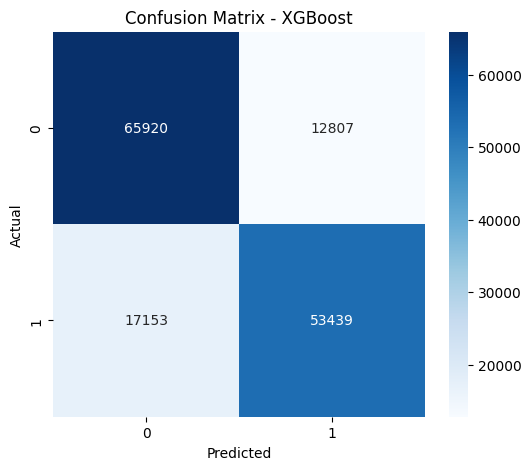

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [15]:
importance = model.feature_importances_
features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

                   Feature  Importance
4             My_Hand_Size    0.271633
8                Pip_Count    0.079135
0                 Left_End    0.070699
3                   Tile_B    0.048151
15                 Count_6    0.046254
1                Right_End    0.043762
7                Is_Double    0.041645
23  Is_Opponent_Vulnerable    0.041576
2                   Tile_A    0.040392
6            Boneyard_Size    0.036585


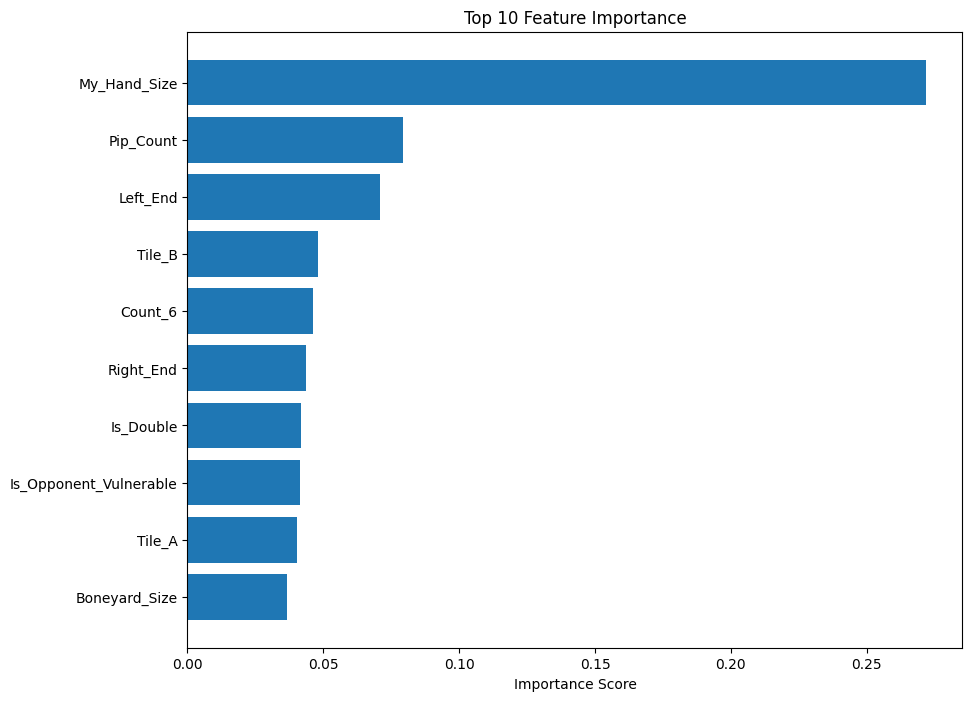

In [16]:
plt.figure(figsize=(10,8))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance Score')
plt.show()

In [17]:
import joblib

joblib.dump(model, 'xgboost_domino_model.pkl')

print('Model berhasil disimpan!')

Model berhasil disimpan!
